In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/dataset.csv')
df

,Linera density,Density yarn,Strength Gpa,Module Gpa,lengthening,Mass size,breaking the loop,Surface density of the fabric,Prepreg surface density,Resin content,viscosity,Gelation time,Resin Tg,technology,Thickness of the monolayer,density,Strength_plastik,Module_plastik,LSS,Plastik_Tg
0,188.0,1.758,4.590,253.0,1.814229,1.000000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,v,0.2090,1.5360,879.0,70.1,77.20,164.0
1,189.0,1.758,4.480,260.0,1.723077,1.100000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,v,0.2090,1.5360,879.0,70.1,77.20,164.0
2,188.0,1.759,4.280,257.0,1.665370,1.000000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,v,0.2090,1.5360,879.0,70.1,77.20,164.0
3,187.0,1.758,4.770,256.0,1.863281,1.000000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,v,0.2090,1.5360,879.0,70.1,77.20,164.0
4,190.0,1.757,4.560,255.0,1.788235,0.900000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,v,0.2090,1.5360,879.0,70.1,77.20,164.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11123,189.0,1.783,4.640,271.0,1.712177,1.283333,23.5,206.0,335.9,38.30,23.420,16.78,150.44,v,0.2235,1.5215,899.0,71.0,86.45,163.0
11124,189.0,1.780,4.500,284.0,1.584507,1.283333,23.5,206.0,335.9,38.30,23.420,16.78,150.44,v,0.2235,1.5215,899.0,71.0,86.45,163.0
11125,190.0,1.783,4.838,270.0,1.791852,1.283333,23.5,206.0,335.9,38.30,23.420,16.78,150.44,v,0.2235,1.5215,899.0,71.0,86.45,163.0
11126,191.0,1.779,4.820,271.0,1.778598,1.283333,23.5,206.0,335.9,38.30,23.420,16.78,150.44,v,0.2235,1.5215,899.0,71.0,86.45,163.0


In [3]:
df['technology'] = df['technology'].replace('v', 0)
df['technology'] = df['technology'].replace('a', 1)

/tmp/ipykernel_7695/3132601926.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['technology'] = df['technology'].replace('a', 1)


In [4]:
df['technology'].value_counts()

technology
1    6915
0    4213
Name: count, dtype: int64

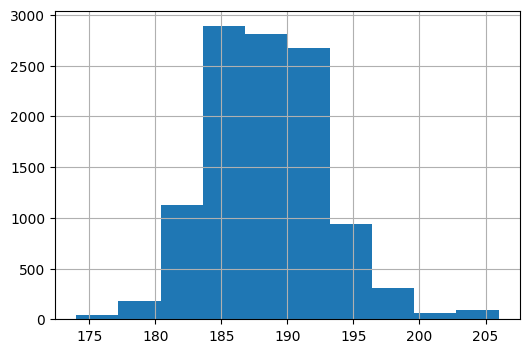

In [ ]:
#оценка разброса линейной плотности УВ
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Linera density']
ax.hist(y)
ax.grid()

plt.show()

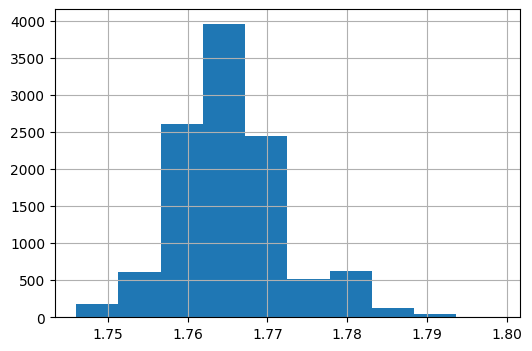

In [ ]:
#оценка разброса плотности УВ
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Density yarn']
ax.hist(y)
ax.grid()

plt.show()

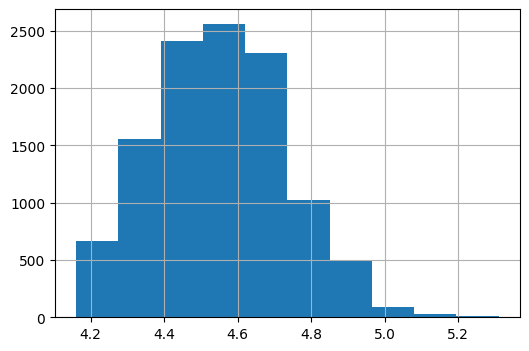

In [ ]:
#оценка разброса прочности при растяжении УВ в микропластике
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Strength Gpa']
ax.hist(y)
ax.grid()

plt.show()

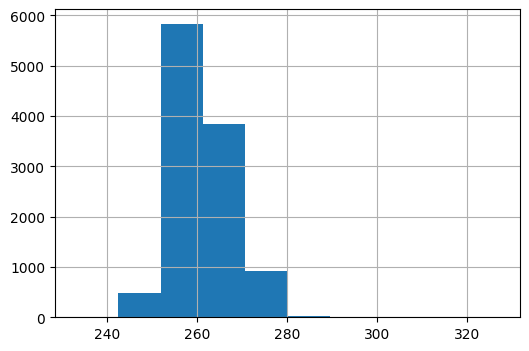

In [ ]:
#оценка разброса модуля упругости при растяжении УВ в микропластике
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Module Gpa']
ax.hist(y)
ax.grid()

plt.show()

In [9]:
df['Module Gpa'].describe()

count    11128.000000
mean       260.987716
std          6.667140
min        233.000000
25%        256.000000
50%        260.000000
75%        265.000000
max        327.000000
Name: Module Gpa, dtype: float64

In [14]:
df[df['Module Gpa'] > 300]

,Linera density,Density yarn,Strength Gpa,Module Gpa,lengthening,Mass size,breaking the loop,Surface density of the fabric,Prepreg surface density,Resin content,viscosity,Gelation time,Resin Tg,technology,Thickness of the monolayer,density,Strength_plastik,Module_plastik,LSS,Plastik_Tg
4387,197.0,1.766,5.31,327.0,1.623853,1.257778,27.5,208.0,332.435,37.365,31.926667,16.526667,151.723333,0,0.2105,1.5240,920.000,70.800,76.35,159.5
4807,197.0,1.766,5.31,327.0,1.623853,1.257778,27.5,208.0,329.150,36.770,31.660000,14.665000,151.835000,1,0.1995,1.5615,1025.000,74.300,77.40,159.5
9456,197.0,1.766,5.31,327.0,1.623853,1.257778,27.5,206.0,327.315,38.065,22.400000,12.860000,149.140000,1,0.2140,1.5440,951.515,63.435,85.25,160.5
9876,197.0,1.766,5.31,327.0,1.623853,1.257778,27.5,206.5,334.235,38.165,28.100000,14.000000,146.330000,0,0.2215,1.5255,857.700,72.945,87.80,165.0


Модуль упругости выше 300 ГПа - выбросы.

Эти строки необходимо удалить

In [18]:
df = df.drop(df[df['Module Gpa'] == 327].index)

df[df['Module Gpa'] > 300]

,Linera density,Density yarn,Strength Gpa,Module Gpa,lengthening,Mass size,breaking the loop,Surface density of the fabric,Prepreg surface density,Resin content,viscosity,Gelation time,Resin Tg,technology,Thickness of the monolayer,density,Strength_plastik,Module_plastik,LSS,Plastik_Tg


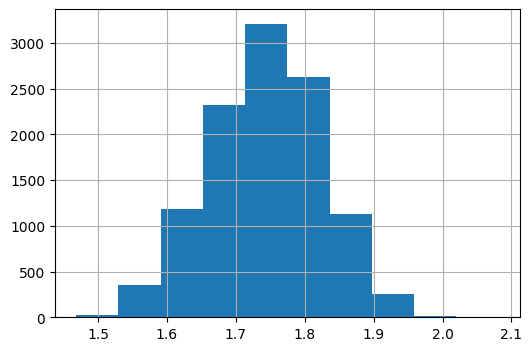

In [19]:
#оценка разброса удлинения при растяжении УВ в микропластике
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['lengthening']
ax.hist(y)
ax.grid()

plt.show()

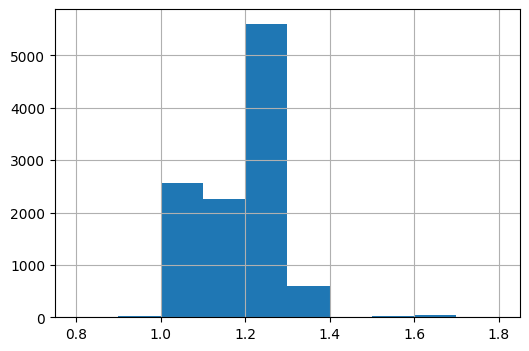

In [ ]:
#оценка разброса содержания аппрета на УВ
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Mass size']
ax.hist(y)
ax.grid()

plt.show()

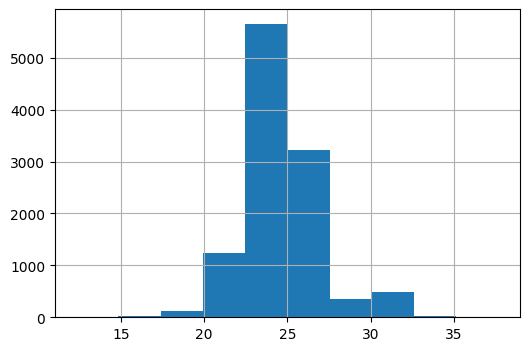

In [ ]:
#оценка разброса прочности при разрыве УВ в петле
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['breaking the loop']
ax.hist(y)
ax.grid()

plt.show()

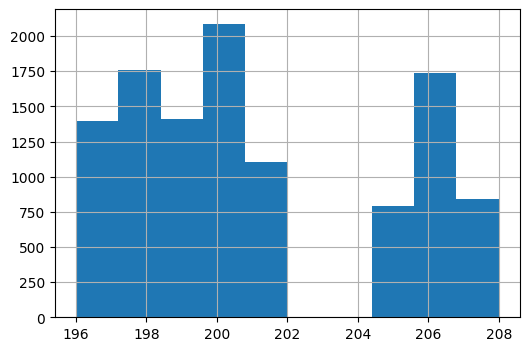

In [ ]:
#оценка разброса поверхностной плотности ткани из УВ
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Surface density of the fabric']
ax.hist(y)
ax.grid()

plt.show()

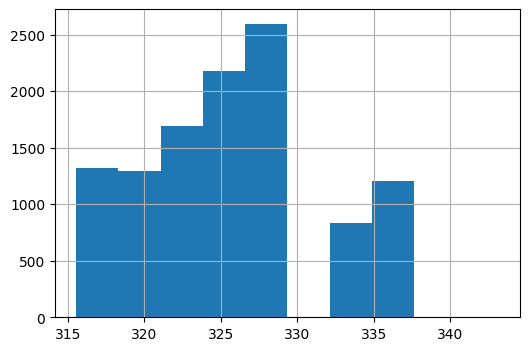

In [ ]:
#оценка разброса поверхностной плотности препрега
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Prepreg surface density']
ax.hist(y)
ax.grid()

plt.show()

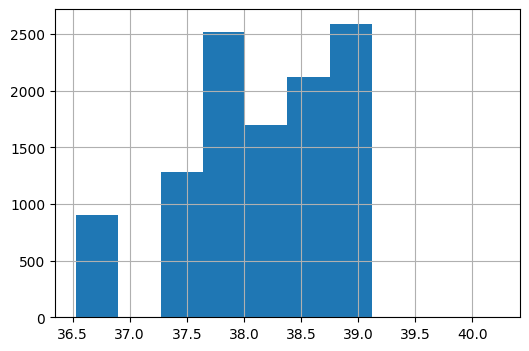

In [ ]:
#оценка разброса содержания связующего в препреге
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Resin content']
ax.hist(y)
ax.grid()

plt.show()

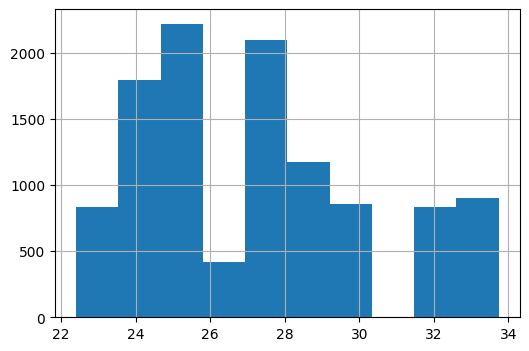

In [ ]:
#оценка разброса вязкости связующего
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['viscosity']
ax.hist(y)
ax.grid()

plt.show()

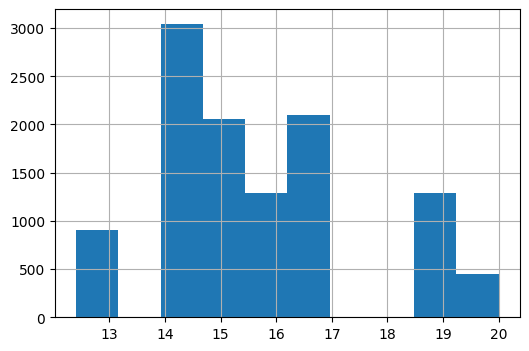

In [29]:
#оценка разброса времени гелеобразования связующего
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Gelation time']
ax.hist(y)
ax.grid()

plt.show()

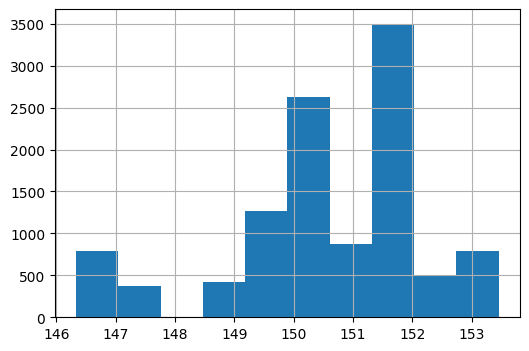

In [ ]:
#оценка разброса температуры стеклования
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Resin Tg']
ax.hist(y)
ax.grid()

plt.show()

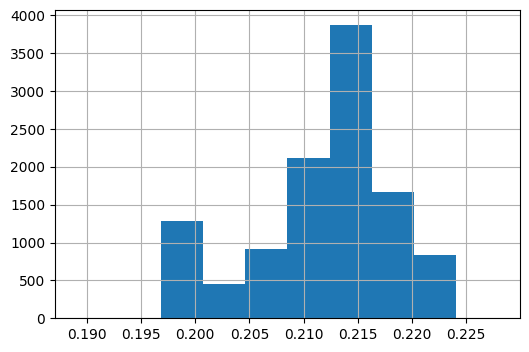

In [ ]:
#оценка разброса толщины монослоя в пластике
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Thickness of the monolayer']
ax.hist(y)
ax.grid()

plt.show()

In [32]:
df.head(3)

,Linera density,Density yarn,Strength Gpa,Module Gpa,lengthening,Mass size,breaking the loop,Surface density of the fabric,Prepreg surface density,Resin content,viscosity,Gelation time,Resin Tg,technology,Thickness of the monolayer,density,Strength_plastik,Module_plastik,LSS,Plastik_Tg
0,188.0,1.758,4.59,253.0,1.814229,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
1,189.0,1.758,4.48,260.0,1.723077,1.1,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
2,188.0,1.759,4.28,257.0,1.665370,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0


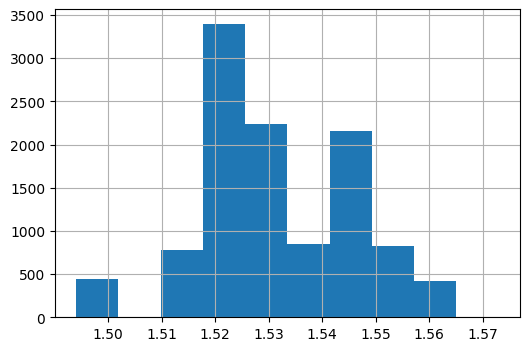

In [ ]:
#оценка разброса плотности углепластика
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['density']
ax.hist(y)
ax.grid()

plt.show()

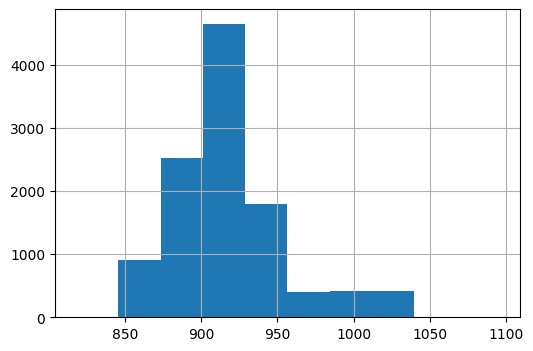

In [35]:
#оценка разброса прочности углепластика
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Strength_plastik']
ax.hist(y)
ax.grid()

plt.show()

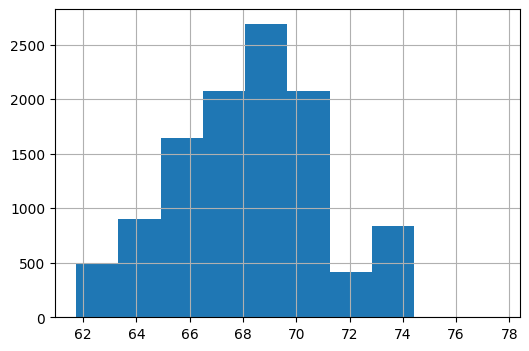

In [38]:
#оценка разброса модуля упругости углепластика
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Module_plastik ']
ax.hist(y)
ax.grid()

plt.show()

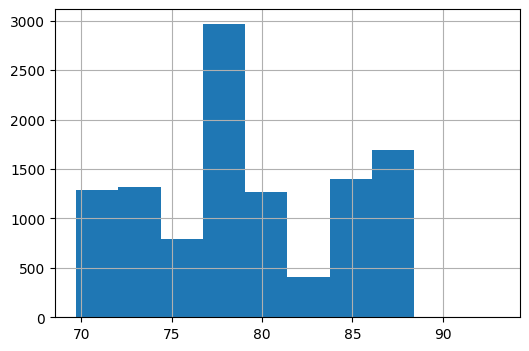

In [ ]:
#оценка разброса прочности при межслоевом свдиге углепластика
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['LSS']
ax.hist(y)
ax.grid()

plt.show()

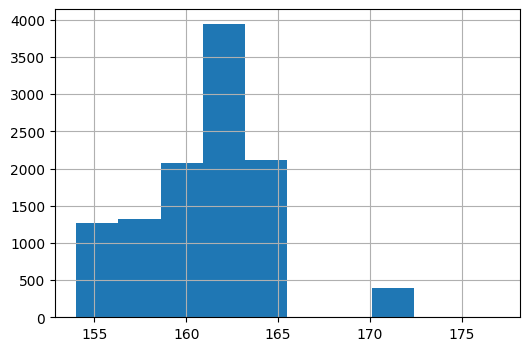

In [40]:
#оценка разброса прочности при межслоевом свдиге углепластика
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()

y = df['Plastik_Tg']
ax.hist(y)
ax.grid()

plt.show()

In [44]:
df.to_csv('data/dataset_prepaired.csv', index=False, encoding='utf-8')